# Diabetes Risk Prediction

## Objective
The goal of this project is to predict the **risk of diabetes** based on patient data, including demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of individuals with features relevant to diabetes risk assessment.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for diabetes risk.
4. **Model Training**: Train a classification model to predict diabetes risk.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from sklearn.preprocessing import StandardScaler


In [2]:

# Load the dataset
df = pd.read_csv('framingham.csv')

# Display basic information about the dataset

print("--- Dataset Dimensions ---")
print(f"Data shape: {df.shape}\n")

print("--- Datatype Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Dimensions ---
Data shape: (4240, 16)

--- Datatype Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

--- Check for missing values ---
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
(3658, 16)


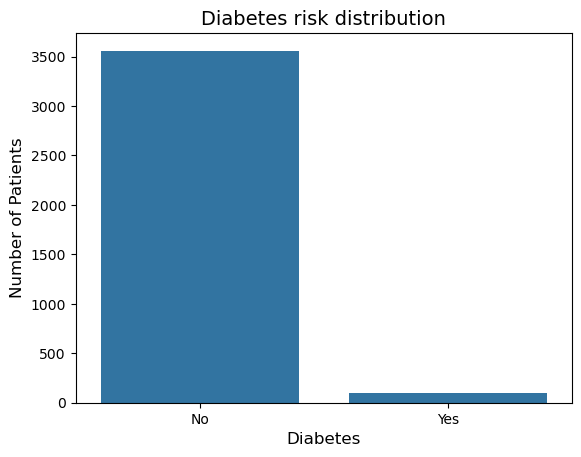

In [3]:

# Check for missing values
print("--- Check for missing values ---")
print(df.isnull().sum())

# remove null(if any)
df = df.dropna()
print(df.shape)

# Visualize diabetes risk distribution
df['diabetes'] = df['diabetes'].map({0:'No', 1: 'Yes'})
sns.countplot(data= df, x= 'diabetes')
plt.title('Diabetes risk distribution', fontsize= 14)
plt.xlabel("Diabetes", fontsize= 12)
plt.ylabel("Number of Patients", fontsize= 12)

plt.show()

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

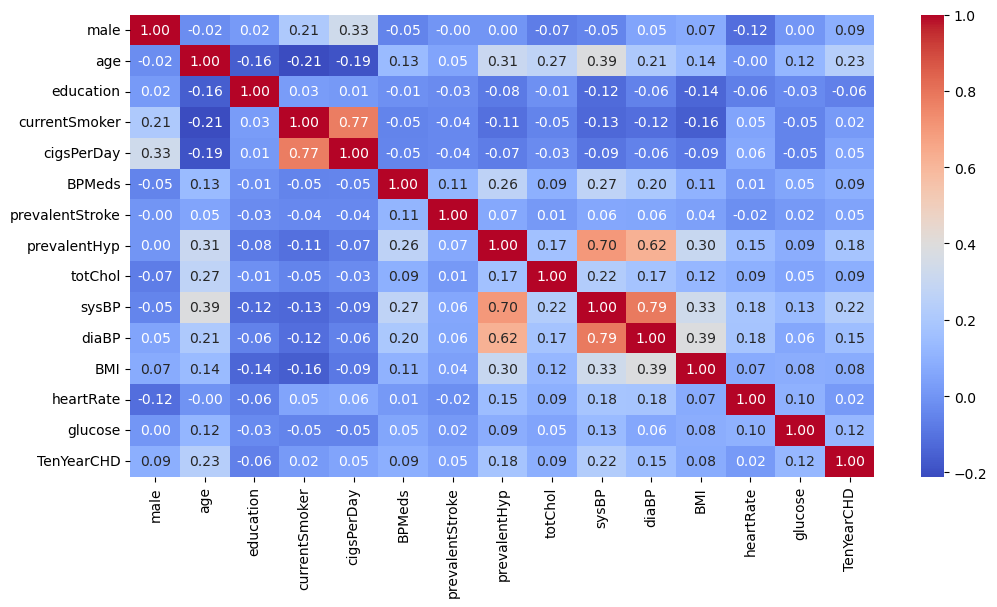

In [4]:
plt.figure(figsize=(12,6))
corr= df.corr(numeric_only=True)
sns.heatmap(corr, annot= True, cmap= 'coolwarm', fmt='.2f')
plt.show()

## A Heatmap to see how correlated columns are

### Observation


#### Strongest Positive Relationships

* *sysBP & diaBP (0.79): Systolic and diastolic blood pressures increase together.*
* *currentSmoker & cigsPerDay (0.77): Smoking status links tightly with higher cigarette consumption.*
* *diabetes & glucose (0.61): High blood sugar levels align strongly with diabetes.*
* *sysBP & prevalentHyp (0.70): High systolic blood pressure connects strongly to existing hypertension.*

#### Primary Predictors

* *age (0.23)*
* *sysBP (0.22)*
* *prevalentHyp (0.18)*
* *glucose (0.12)*

#### Notable Negative & Weak Relationships

* *education & currentSmoker (-0.21)*
* *education & age (-0.16)*
* *BMI & heartRate (0.07)*

In [5]:
# Drop unnecessary columns (e.g., Patient ID if present)


# Encode categorical variables
# df = pd.get_dummies(df, drop_first=True)


# Define features and target variable

y = df['diabetes']
X = df.drop('diabetes', axis=1)


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

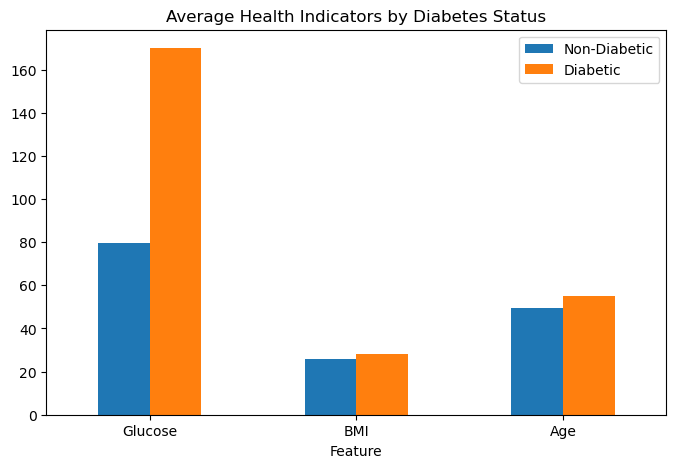

In [6]:
comparison = {
    'Feature': ['Glucose', 'BMI', 'Age'],
    'Non-Diabetic': [79.40, 25.72, 49.40],
    'Diabetic': [169.96, 27.95, 55.15]
}

comp_df = pd.DataFrame(comparison)

comp_df.set_index('Feature').plot(kind='bar', figsize=(8,5))
plt.title('Average Health Indicators by Diabetes Status')
plt.ylabel('')
plt.xticks(rotation=0)

plt.show()

### Conclusion
* *Exploratory analysis revealed that glucose level was substantially higher among diabetic individuals (169.96 mg/dL) compared to non-diabetic individuals (79.40 mg/dL). This suggests that glucose is a highly influential predictor and is expected to play a significant role in the Logistic Regression model.*

### Challenge

* *In real world, glucose level is one of the primary measurements doctors use to diagnose diabetes.*
* *If a patient has very high glucose, the model is almost being told the answer. For a real-world predictive model, that can be considered data leakage*

### Solution

* *Building 2 Models: 1st with Glucose, 2nd Without Glucose.*

## Model Training
Train a **Logistic Regression** model to predict diabetes risk.

MODEL 1 (WITH GLUCOSE)
Accuracy: 90.30%

Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.91      0.95       712
         Yes       0.19      0.75      0.30        20

    accuracy                           0.90       732
   macro avg       0.59      0.83      0.62       732
weighted avg       0.97      0.90      0.93       732


Confusion Matrix:


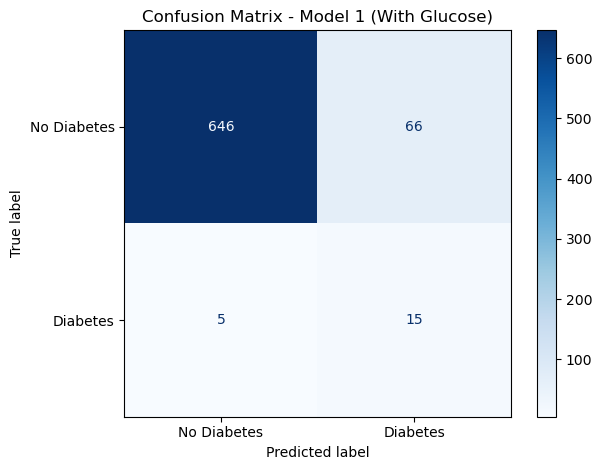

In [7]:
# Train a Logistic Regression model

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model1 = LogisticRegression(max_iter=1000, class_weight='balanced')

model1.fit(X_train_scaled, y_train)

# Predictions

y_pred1 = model1.predict(X_test_scaled)


# Model evaluation

print("MODEL 1 (WITH GLUCOSE)")
print(f"Accuracy:{accuracy_score(y_test, y_pred1)*100: .2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred1))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred1)

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Model 1 (With Glucose)')
plt.tight_layout()
plt.savefig("model1.png", dpi=600)
plt.show()

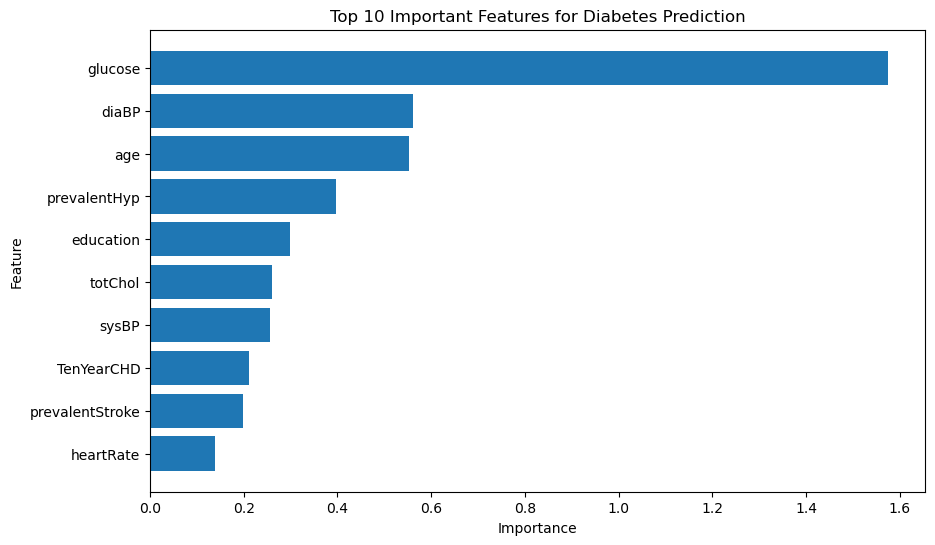

In [8]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_[0]})

coef_df['Importance'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values('Importance', ascending=False)

# Top 10 Features
top_features = coef_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])

plt.title('Top 10 Important Features for Diabetes Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

MODEL 2 (WITHOUT GLUCOSE)
Accuracy: 72.13%

Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.72      0.83       712
         Yes       0.07      0.75      0.13        20

    accuracy                           0.72       732
   macro avg       0.53      0.74      0.48       732
weighted avg       0.97      0.72      0.81       732


Confusion Matrix:


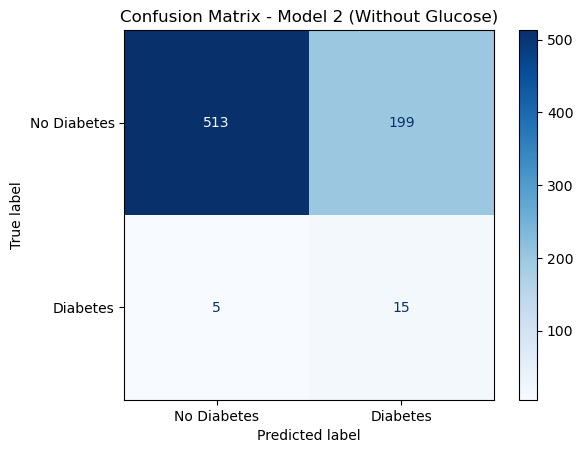

In [9]:
# Features and Target
X = df.drop(['diabetes', 'glucose'], axis=1)
y = df['diabetes']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model2 = LogisticRegression(max_iter=1000, class_weight='balanced')

model2.fit(X_train_scaled, y_train)

# Predictions
y_pred2 = model2.predict(X_test_scaled)

# Evaluation
print("MODEL 2 (WITHOUT GLUCOSE)")
print(f"Accuracy:{accuracy_score(y_test, y_pred2)* 100: .2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred2)

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Model 2 (Without Glucose)')
plt.show()

## Key Observations

* Both models achieved the same **Recall (75%)**, correctly identifying **15 out of 20 diabetic patients**.
* Model 1 achieved significantly higher **Accuracy (90.30% vs 72.13%)**.
* Model 1 achieved much higher **Precision (19% vs 7%)**, meaning fewer false positive diabetes predictions.
* The higher performance of Model 1 is largely due to the inclusion of the **glucose** feature, which is strongly associated with diabetes diagnosis.

## Conclusion

* **Model 1 (With Glucose)** produced the best overall performance and is the preferred model for diabetes classification.
* **Model 2 (Without Glucose)** demonstrated that other health indicators such as age, BMI, blood pressure, cholesterol, and smoking habits can contribute to prediction, but with substantially lower effectiveness.
* The comparison confirms that **glucose is the most influential feature in predicting diabetes within this dataset.**
